In [1]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys
import seaborn as sns
import plotly.graph_objects as go
from collections import defaultdict
from scipy.spatial import cKDTree

import nbimporter
from read_plot_voxelization import export_filtered_las, show_voxelgrid_plotly, point_cloud_to_dataframe

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Voxelization
This step converts points into voxels of a defined resolution to reduce point cloud density.

In [2]:
import plotly.graph_objects as go
import open3d as o3d

def show_pcd_plotly(pcd: o3d.geometry.PointCloud, marker_size=2):
    P = np.asarray(pcd.points)
    if P.size == 0:
        raise ValueError("PointCloud is empty.")
    if pcd.has_colors():
        C = (np.asarray(pcd.colors) * 255).astype(np.uint8)
        col = [f"rgb({r},{g},{b})" for r,g,b in C]
    else:
        col = "rgb(0,120,255)"

    fig = go.Figure(data=[go.Scatter3d(
        x=P[:,0], y=P[:,1], z=P[:,2],
        mode="markers",
        marker=dict(size=marker_size, color=col, opacity=0.95)
    )])
    fig.update_layout(scene_aspectmode="data", margin=dict(l=0,r=0,t=0,b=0))
    fig.show()


def show_voxelgrid_plotly(vg: o3d.geometry.VoxelGrid, marker_size=3):
    #Takes each voxel from the Open3D VoxelGrid

    #Computes its real XYZ center

    #Retrieves the voxel’s color (if available)

    #Converts the color into a Plotly-compatible format

    #Plots all voxels in 3D as colored points in an interactive Plotly view

    voxels = vg.get_voxels()
    if len(voxels) == 0:
        raise ValueError("VoxelGrid is empty.")
    
    # Centers calculation
    centers = np.array([vg.get_voxel_center_coordinate(v.grid_index) for v in voxels])

    colors = []
    for v in voxels:
        if hasattr(v, "color") and v.color is not None:
            c = (np.asarray(v.color) * 255).astype(np.uint8)
            colors.append(f"rgb({c[0]},{c[1]},{c[2]})")
        else:
            colors.append("rgb(200,200,200)")
    fig = go.Figure(data=[go.Scatter3d(
        x=centers[:,0], y=centers[:,1], z=centers[:,2],
        mode="markers",
        marker=dict(size=marker_size, color=colors, opacity=0.95)
    )])
    fig.update_layout(scene_aspectmode="data", margin=dict(l=0,r=0,t=0,b=0))
    fig.show()

Method for visualization using OffscreenRenderer - not important for voxelization algorithm

In [3]:
def render_geometry_offscreen(geom, width=1280, height=720, shader="defaultUnlit"):
    import open3d as o3d, numpy as np
    from matplotlib import pyplot as plt

    renderer = o3d.visualization.rendering.OffscreenRenderer(width, height)
    mat = o3d.visualization.rendering.MaterialRecord()
    mat.shader = shader
    renderer.scene.add_geometry("obj", geom, mat)

    aabb = geom.get_axis_aligned_bounding_box()
    center = aabb.get_center().astype(np.float32)
    eye = center + np.array([0, 0, 2.5*np.linalg.norm(aabb.get_extent())], dtype=np.float32)
    up = np.array([0, 1, 0], dtype=np.float32)
    renderer.setup_camera(60.0, center, eye, up)

    img = renderer.render_to_image()
    plt.imshow(np.asarray(img))
    plt.axis("off")
    plt.show()


#### Algorithm implementation

In [4]:
las_path  = "../datasource/4VOLCALC.las"

In [5]:
point_cloud = laspy.read(las_path)
xyz = np.vstack((point_cloud.x, point_cloud.y, point_cloud.z)).T.astype(np.float32)
rgb = np.vstack((point_cloud.red, point_cloud.green, point_cloud.blue)).transpose()/65535

In [6]:
pcd = o3d.geometry.PointCloud()

In [7]:
pcd.points = o3d.utility.Vector3dVector(xyz)
pcd.colors = o3d.utility.Vector3dVector(rgb)

In [8]:
vsize = max(pcd.get_max_bound()-pcd.get_min_bound()) * 0.01
vsize = round(vsize,4)
print(vsize)

0.125


In [9]:
print(np.asarray(pcd.points).shape)

(28456, 3)


In [10]:
pcd_reduced = pcd.voxel_down_sample(voxel_size=vsize)

voxel_grid=o3d.geometry.VoxelGrid.create_from_point_cloud(pcd_reduced, voxel_size=vsize)
min_bound = voxel_grid.get_min_bound()
max_bound = voxel_grid.get_max_bound()
bounds = max_bound - min_bound
print("Min coordinates:", min_bound)
print("Max coordinates:", max_bound)
print("Bounds:", bounds)
print("Voxel numbers:", len(voxel_grid.get_voxels()))

Min coordinates: [2.73517812e+05 5.01868194e+06 3.80674992e+01]
Max coordinates: [2.73523688e+05 5.01869456e+06 4.01924992e+01]
Bounds: [ 5.875 12.625  2.125]
Voxel numbers: 1375


In [11]:
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=vsize)
print("Number of voxels:", len(voxel_grid.get_voxels()))

Number of voxels: 1486


In [12]:
bounds=voxel_grid.get_max_bound()-voxel_grid.get_min_bound()

In [13]:
o3d.visualization.draw_geometries([voxel_grid])

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x5ddc45561cd0 (threading is enabled)
EGL(1.5)
OpenGL(4.6)


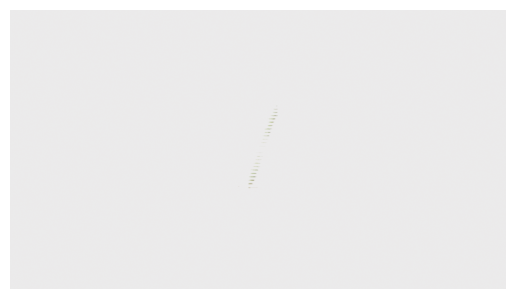

In [14]:
render_geometry_offscreen(voxel_grid)

Voxelgrid with full PCD

In [15]:
show_voxelgrid_plotly(voxel_grid, marker_size=4)
print(len(voxel_grid.get_voxels()))

1486


Voxelgrid with reduced PCD

In [16]:
voxel_grid_reduced = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd_reduced, voxel_size=vsize)
show_voxelgrid_plotly(voxel_grid_reduced, marker_size=4)

Minimal distance between voxel centers

In [17]:
import numpy as np
import open3d as o3d

voxels = voxel_grid.get_voxels()
centers = np.array([
    voxel_grid.get_voxel_center_coordinate(v.grid_index)
    for v in voxels
])

X = centers[:, 0]
Y = centers[:, 1]
Z = centers[:, 2]
n = len(centers)

min_dx = float("inf")
min_dy = float("inf")
min_dz = float("inf")
min_dist_xy = float("inf")
min_dist_xyz = float("inf")

pair_dx = pair_dy = pair_dz = pair_xy = pair_xyz = (None, None)

for i in range(n):
    for j in range(i+1, n):

        dx = abs(X[i] - X[j])
        dy = abs(Y[i] - Y[j])
        dz = abs(Z[i] - Z[j])

        dist_xy = np.hypot(dx, dy)
        dist_xyz = np.linalg.norm(centers[i] - centers[j])

        if dx < min_dx:
            min_dx = dx
            pair_dx = (i, j)

        if dy < min_dy:
            min_dy = dy
            pair_dy = (i, j)

        if dz < min_dz:
            min_dz = dz
            pair_dz = (i, j)

        if dist_xy < min_dist_xy:
            min_dist_xy = dist_xy
            pair_xy = (i, j)

        if dist_xyz < min_dist_xyz:
            min_dist_xyz = dist_xyz
            pair_xyz = (i, j)

def show_pair(name, pair, value):
    i, j = pair
    print(f"\n{name}: {value}")
    print("  Voxel A:", centers[i])
    print("  Voxel B:", centers[j])

show_pair("Min 3D (XYZ) distance", pair_xyz, min_dist_xyz)



Min 3D (XYZ) distance: 0.125
  Voxel A: [2.73521125e+05 5.01868600e+06 3.93499985e+01]
  Voxel B: [2.73521125e+05 5.01868600e+06 3.94749985e+01]


Voxmesh even if it's not ideal for volume aprox.

In [18]:
import open3d as o3d
import numpy as np

def voxelgrid_to_cubes(voxel_grid, cube_size):
    voxels = voxel_grid.get_voxels()
    centers = np.array([
        voxel_grid.get_voxel_center_coordinate(v.grid_index)
        for v in voxels
    ])

    cube_list = []

    for v, center in zip(voxels, centers):
        cube = o3d.geometry.TriangleMesh.create_box(width=cube_size,
                                                    height=cube_size,
                                                    depth=cube_size)
        cube.translate(center - np.array([cube_size/2,
                                          cube_size/2,
                                          cube_size/2]))

        #Use voxel if has a color
        if hasattr(v, "color") and v.color is not None:
            cube.paint_uniform_color(v.color)
        else:
            cube.paint_uniform_color([0.6, 0.6, 0.6])

        cube_list.append(cube)

    # Connect all cubes in geometry
    full_mesh = o3d.geometry.TriangleMesh()
    for mesh in cube_list:
        full_mesh += mesh

    full_mesh.compute_vertex_normals()
    return full_mesh


cube_size = vsize
mesh = voxelgrid_to_cubes(voxel_grid, cube_size)

#o3d.visualization.draw(mesh)


def o3d_mesh_to_plotly(mesh, color=(150, 150, 150)):
    # Extract vertices and triangles
    verts = np.asarray(mesh.vertices)
    tris = np.asarray(mesh.triangles)

    # Convert color to RGB (0-255)
    r, g, b = color
    color_str = f"rgb({r},{g},{b})"

    # Create Plotly Mesh3D
    fig = go.Figure(data=[
        go.Mesh3d(
            x=verts[:, 0],
            y=verts[:, 1],
            z=verts[:, 2],
            i=tris[:, 0],
            j=tris[:, 1],
            k=tris[:, 2],
            color=color_str,
            opacity=1.0,
            flatshading=True
        )
    ])

    fig.update_layout(
        scene=dict(aspectmode="data"),
        width=900,
        height=700,
        margin=dict(l=0, r=0, t=0, b=0)
    )

    fig.show()

o3d_mesh_to_plotly(mesh, color=(180, 180, 220))
N = len(voxel_grid.get_voxels())
print(N)
print(vsize)
volume = N * (vsize ** 3)
print("Volume (m³):", volume)

1486
0.125
Volume (m³): 2.90234375


In [19]:
len(voxel_grid.get_voxels())

1486

### Custom voxelization 

In [20]:
import numpy as np
from collections import defaultdict

# 
# 1) COMPUTE MEAN DISTANCE BETWEEN POINTS (WITHOUT OUTLIERS)
# 

def mean_point_spacing_kdtree(points, k=10, percentile_cut=95, sample_size=20000, seed=0):
    """
    Fast estimate of typical point spacing using a KD-tree.

    points: (N,3)
    k: number of neighbors (excluding self) to include in the statistic
    percentile_cut: trim distances above this percentile (removes outliers)
    sample_size: if not None, use only this many random points to estimate spacing
    """
    points = np.asarray(points, dtype=np.float64)
    n = len(points)
    if n == 0:
        return 0.0

    if sample_size is not None and sample_size < n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=sample_size, replace=False)
        query_pts = points[idx]
    else:
        query_pts = points

    try:
        from scipy.spatial import cKDTree
    except ImportError as e:
        raise ImportError("SciPy not installed. Install scipy or use the Open3D fallback below.") from e

    tree = cKDTree(points)

    # query returns self as the first neighbor with distance 0, so ask for k+1 and drop first column
    dists, _ = tree.query(query_pts, k=min(k + 1, n))
    dists = dists[:, 1:]  # drop self

    d = dists.reshape(-1)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return 0.0

    cutoff = np.percentile(d, percentile_cut)
    d = d[d < cutoff]
    return float(d.mean()) if d.size else float(cutoff)

# def mean_point_spacing(points, k=10, percentile_cut=95):
#     """
#     Computes mean nearest-neighbor distance without outliers.
#     points: Nx3 numpy array
#     k: number of neighbors to consider for spacing
#     percentile_cut: remove distances above this percentile
#     """
#     N = points.shape[0]
#     distances = []

#     for i in range(N):
#         # Compute distance to all points (brutal but simple)
#         d = np.linalg.norm(points - points[i], axis=1)
#         d = np.sort(d)[1:k+1]  # ignore zero distance to itself
#         distances.extend(d)

#     distances = np.array(distances)

#     # Remove outliers
#     cutoff = np.percentile(distances, percentile_cut)
#     distances_filtered = distances[distances < cutoff]

#     return distances_filtered.mean()


# 
# 2) VOXELIZATION USING MEAN DISTANCE AS VOXEL SIZE
#    + REMOVE POINTS ONCE A VOXEL IS CREATED
# 

def voxelize_custom(points, voxel_size):
    """
    Custom voxelization: 
    - creates a voxel only once for each (i,j,k)
    - removes all points inside a voxel once voxel is created
    
    Returns:
    voxel_dict = {(i,j,k): voxel_center}
    remaining_points = points NOT consumed (optional)
    """

    min_bound = points.min(axis=0)
    voxel_dict = {}
    consumed = set()

    for idx, p in enumerate(points):
        # Skip point if already consumed
        if idx in consumed:
            continue

        # Compute voxel index
        voxel_index = tuple(np.floor((p - min_bound) / voxel_size).astype(int))

        # Create voxel if doesn't exist
        if voxel_index not in voxel_dict:

            # Compute voxel center
            voxel_center = min_bound + (np.array(voxel_index) + 0.5) * voxel_size
            voxel_dict[voxel_index] = voxel_center

            # Remove all other points inside this voxel
            # (vectorized check)
            diffs = (points - min_bound) / voxel_size
            indices = np.floor(diffs).astype(int)
            mask = np.all(indices == voxel_index, axis=1)

            for j in np.where(mask)[0]:
                consumed.add(j)

    remaining = points[[i for i in range(len(points)) if i not in consumed]]
    return voxel_dict, remaining


# EXAMPLE USAGE
# 

def custom_voxel_pipeline(pcd):
    print("Start of the pipeline")
    points = np.asarray(pcd.points)
    print("Points : ", len(points))
    #compute spacing
    mean_dist = mean_point_spacing_kdtree(points) 
    print("Mean spacing (voxel size):", mean_dist)

    #voxelization
    voxels, remaining = voxelize_custom(points, mean_dist)
    print("Created voxels:", len(voxels))
    print("Remaining points:", len(remaining))

    return voxels, mean_dist


In [21]:
#voxels, mean_dist = custom_voxel_pipeline(pcd)

In [22]:
def voxel_dict_to_cube_mesh(voxel_dict, voxel_size):
    meshes = []
    half = voxel_size / 2.0

    for center in voxel_dict.values():
        cube = o3d.geometry.TriangleMesh.create_box(voxel_size, voxel_size, voxel_size)
        cube.translate(center - np.array([half, half, half]))
        cube.compute_vertex_normals()
        meshes.append(cube)

    # connect all in one mesh geometry
    full_mesh = meshes[0]
    for m in meshes[1:]:
        full_mesh += m

    return full_mesh

In [23]:
#voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=mean_dist)
N = len(voxel_grid.get_voxels())
#volume = N * (mean_dist ** 3)

#print("vsize:", mean_dist)
print("N voxels:", N)
print("Volume:", volume)

N voxels: 1486
Volume: 2.90234375


In [24]:
#mesh = voxel_dict_to_cube_mesh(voxels, mean_dist)

cube_size = 0.0175 

#o3d_mesh_to_plotly(mesh, color=(180, 180, 220))

### Voxelization using -> (Open3D 0.19.0. documentation)

In [25]:
pcd.scale(1 / np.max(pcd.get_max_bound() - pcd.get_min_bound()),
          center=pcd.get_center())
pcd.colors = o3d.utility.Vector3dVector(np.random.uniform(0, 1, size=(N, 3)))
o3d.visualization.draw_geometries([pcd])


In [ ]:
vsize = 0.005
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd,
                                                            voxel_size=vsize)
o3d.visualization.draw_geometries([voxel_grid])


Voxel size: 0.005
Number of voxels: 4331
Approx. volume: 0.0005413750000000001
